# Flexible Dataset Generation

Generate diverse fractal cube datasets by sampling k_min, k_max, sigma randomly from specified ranges.

## Setup

In [1]:
import sys
import os
import numpy as np
import h5py
import json
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import time

# Setup paths
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root / 'src'))
sys.path.insert(0, str(project_root / 'src' / 'pyFC_lib'))

from param_sampler import ParameterSampler, DistributionConfig
from dataset_generator import _generate_image_worker

print(f"Project root: {project_root}")

Project root: /home/davas/Documents/cnn_astro


## Configuration

Adjust these values to control dataset generation:

In [ ]:
# Output directory
output_dir = project_root / 'data' / 'raw'
output_dir.mkdir(parents=True, exist_ok=True)

# Image dimensions
image_width = 128
image_height = 128
image_depth = 1

# Generation parameters
num_images = 100000
batch_size = 40

# Parameter ranges (uniform sampling)
kmin_low, kmin_high = 1.0, 32.0
kmax_low, kmax_high = 100.0, 256.0
sigma_low, sigma_high = 0.01, 5.0
mean_low, mean_high = 1.0, 1.0  # Fixed mean
beta = -5.0 / 3.0  # Kolmogorov

print(f"Image dimensions: {image_width}x{image_height}x{image_depth}")
print(f"Number of images: {num_images}")
print(f"Batch size: {batch_size}")
print(f"k_min range: [{kmin_low}, {kmin_high}]")
print(f"k_max range: [{kmax_low}, {kmax_high}]")
print(f"sigma range: [{sigma_low}, {sigma_high}]")

Image dimensions: 128x128x1
Number of images: 100000
Batch size: 10
k_min range: [1.0, 32.0]
k_max range: [100.0, 256.0]
sigma range: [0.01, 5.0]


/home/davas/Documents/cnn_astro/src/param_sampler.py:123: UserWarning: k_max_high=256.0 > Nyquist limit=64.0. Values will be clamped by pyFC.
  warnings.warn(


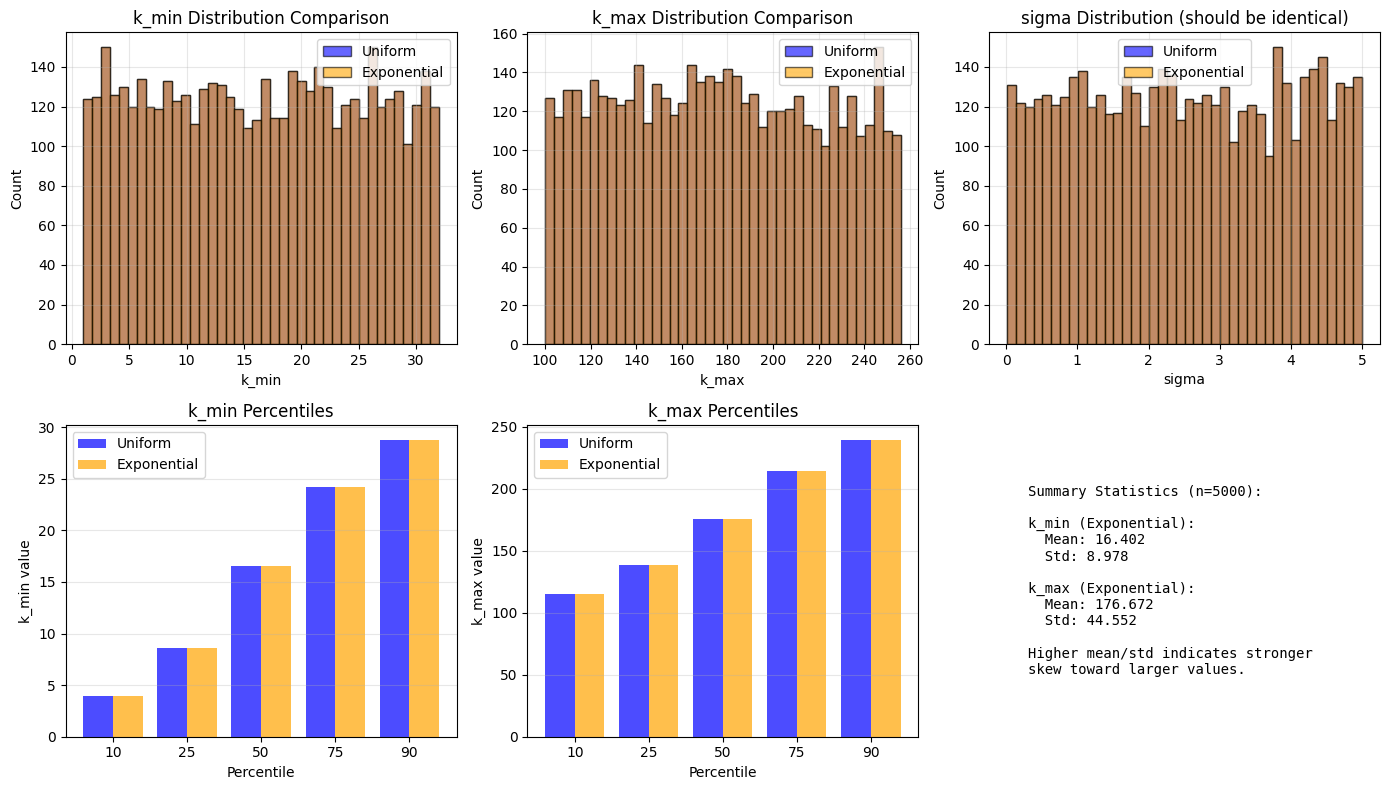

In [3]:
# Compare uniform vs exponential distributions
n_compare = 5000
np.random.seed(42)

# Sample with current distributions
kmin_dist = DistributionConfig(dist_type='uniform')
kmax_dist = DistributionConfig(dist_type='uniform')
sigma_dist = DistributionConfig(dist_type='uniform')

sampler = ParameterSampler(
    image_height=image_height,
    image_width=image_width,
    image_depth=image_depth,
    kmin_range=(kmin_low, kmin_high),
    kmax_range=(kmax_low, kmax_high),
    sigma_range=(sigma_low, sigma_high),
    mean_range=(mean_low, mean_high),
    kmin_dist=kmin_dist,
    kmax_dist=kmax_dist,
    sigma_dist=sigma_dist,
    auto_kmax=False
)

params_exponential = sampler.sample_batch(n_compare, seed=42)

# Sample with uniform distributions for comparison
sampler_uniform = ParameterSampler(
    image_height=image_height,
    image_width=image_width,
    image_depth=image_depth,
    kmin_range=(kmin_low, kmin_high),
    kmax_range=(kmax_low, kmax_high),
    sigma_range=(sigma_low, sigma_high),
    mean_range=(mean_low, mean_high),
    auto_kmax=False
)
params_uniform = sampler_uniform.sample_batch(n_compare, seed=42)

# Create comparison plots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# k_min comparison
axes[0, 0].hist(params_uniform['k_min'], bins=40, alpha=0.6, label='Uniform', color='blue', edgecolor='black')
axes[0, 0].hist(params_exponential['k_min'], bins=40, alpha=0.6, label='Exponential', color='orange', edgecolor='black')
axes[0, 0].set_xlabel('k_min')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('k_min Distribution Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# k_max comparison
axes[0, 1].hist(params_uniform['k_max'], bins=40, alpha=0.6, label='Uniform', color='blue', edgecolor='black')
axes[0, 1].hist(params_exponential['k_max'], bins=40, alpha=0.6, label='Exponential', color='orange', edgecolor='black')
axes[0, 1].set_xlabel('k_max')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('k_max Distribution Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# sigma (should be same)
axes[0, 2].hist(params_uniform['sigma'], bins=40, alpha=0.6, label='Uniform', color='blue', edgecolor='black')
axes[0, 2].hist(params_exponential['sigma'], bins=40, alpha=0.6, label='Exponential', color='orange', edgecolor='black')
axes[0, 2].set_xlabel('sigma')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('sigma Distribution (should be identical)')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Percentile comparison for k_min
percentiles = [10, 25, 50, 75, 90]
uniform_percentiles = [np.percentile(params_uniform['k_min'], p) for p in percentiles]
exponential_percentiles = [np.percentile(params_exponential['k_min'], p) for p in percentiles]
x_pos = np.arange(len(percentiles))
axes[1, 0].bar(x_pos - 0.2, uniform_percentiles, 0.4, label='Uniform', color='blue', alpha=0.7)
axes[1, 0].bar(x_pos + 0.2, exponential_percentiles, 0.4, label='Exponential', color='orange', alpha=0.7)
axes[1, 0].set_xlabel('Percentile')
axes[1, 0].set_ylabel('k_min value')
axes[1, 0].set_title('k_min Percentiles')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(percentiles)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Percentile comparison for k_max
uniform_percentiles = [np.percentile(params_uniform['k_max'], p) for p in percentiles]
exponential_percentiles = [np.percentile(params_exponential['k_max'], p) for p in percentiles]
axes[1, 1].bar(x_pos - 0.2, uniform_percentiles, 0.4, label='Uniform', color='blue', alpha=0.7)
axes[1, 1].bar(x_pos + 0.2, exponential_percentiles, 0.4, label='Exponential', color='orange', alpha=0.7)
axes[1, 1].set_xlabel('Percentile')
axes[1, 1].set_ylabel('k_max value')
axes[1, 1].set_title('k_max Percentiles')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(percentiles)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Summary statistics
axes[1, 2].axis('off')
summary_text = f'Summary Statistics (n={n_compare}):\n\n'
summary_text += f'k_min (Exponential):\n  Mean: {params_exponential["k_min"].mean():.3f}\n  Std: {params_exponential["k_min"].std():.3f}\n\n'
summary_text += f'k_max (Exponential):\n  Mean: {params_exponential["k_max"].mean():.3f}\n  Std: {params_exponential["k_max"].std():.3f}\n\n'
summary_text += f'Higher mean/std indicates stronger\nskew toward larger values.'
axes[1, 2].text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center', family='monospace')

plt.tight_layout()
plt.show()

## Preview Parameter Distributions

In [4]:
# Create sampler
sampler = ParameterSampler(
    image_height=image_height,
    image_width=image_width,
    image_depth=image_depth,
    kmin_range=(kmin_low, kmin_high),
    kmax_range=(kmax_low, kmax_high),
    sigma_range=(sigma_low, sigma_high),
    mean_range=(mean_low, mean_high),
    kmin_dist=kmin_dist,
    kmax_dist=kmax_dist,
    sigma_dist=sigma_dist,
    auto_kmax=False
)

print(f"Sampler: {sampler}")
print(f"Nyquist limit: {sampler.nyquist_limit}")

Sampler: ParameterSampler(image=128x128x1, Nyquist=64.0, k_min=(1.0, 32.0)(uniform), k_max=(100.0, 256.0)(uniform), sigma=(0.01, 5.0)(uniform), mean=(1.0, 1.0))
Nyquist limit: 64.0


/home/davas/Documents/cnn_astro/src/param_sampler.py:123: UserWarning: k_max_high=256.0 > Nyquist limit=64.0. Values will be clamped by pyFC.
  warnings.warn(


## Distribution Configuration

Configure sampling distributions. Set to 'exponential' to favor larger parameter values, or 'uniform' for standard uniform sampling.

In [5]:
# Distribution configuration - exponential favors LARGER values
# For k_min range [1.0, 32.0]: more samples near 32.0
# For k_max range [100.0, 256.0]: more samples near 256.0
# Higher rate = stronger skew toward larger values

kmin_dist = DistributionConfig(dist_type='uniform')  # Strong skew toward 32.0
kmax_dist = DistributionConfig(dist_type='exponential', rate=1.5)  # Moderate skew toward 256.0
sigma_dist = DistributionConfig(dist_type='uniform')  # Keep sigma uniform

print(f'k_min distribution: {kmin_dist.dist_type} (rate={kmin_dist.rate})')
print(f'k_max distribution: {kmax_dist.dist_type} (rate={kmax_dist.rate})')
print(f'sigma distribution: {sigma_dist.dist_type}')

k_min distribution: uniform (rate=1.0)
k_max distribution: exponential (rate=1.5)
sigma distribution: uniform


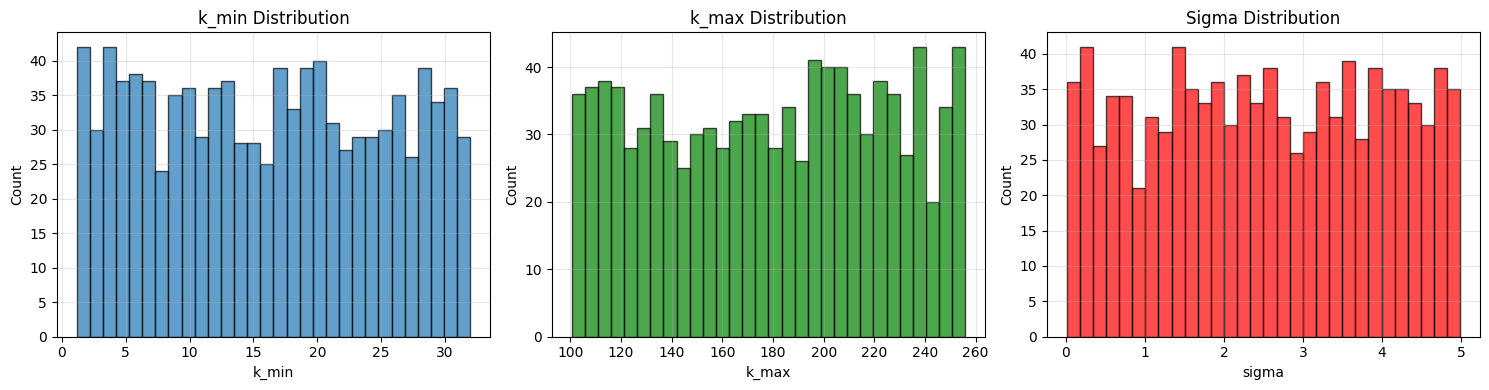

Parameter Statistics (n=1000):
  k_min: 1.144 - 31.991 (mean=16.198)
  k_max: 100.502 - 255.909 (mean=179.095)
  sigma: 0.010 - 4.989 (mean=2.517)


In [6]:
# Preview distributions
n_preview = 1000
preview_params = sampler.sample_batch(n_preview, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(preview_params['k_min'], bins=30, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('k_min')
axes[0].set_ylabel('Count')
axes[0].set_title(f'k_min Distribution')
axes[0].grid(True, alpha=0.3)

axes[1].hist(preview_params['k_max'], bins=30, alpha=0.7, edgecolor='black', color='green')
axes[1].set_xlabel('k_max')
axes[1].set_ylabel('Count')
axes[1].set_title(f'k_max Distribution')
axes[1].grid(True, alpha=0.3)

axes[2].hist(preview_params['sigma'], bins=30, alpha=0.7, edgecolor='black', color='red')
axes[2].set_xlabel('sigma')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Sigma Distribution')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Parameter Statistics (n={n_preview}):")
print(f"  k_min: {preview_params['k_min'].min():.3f} - {preview_params['k_min'].max():.3f} (mean={preview_params['k_min'].mean():.3f})")
print(f"  k_max: {preview_params['k_max'].min():.3f} - {preview_params['k_max'].max():.3f} (mean={preview_params['k_max'].mean():.3f})")
print(f"  sigma: {preview_params['sigma'].min():.3f} - {preview_params['sigma'].max():.3f} (mean={preview_params['sigma'].mean():.3f})")

## Generate Dataset

In [7]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_file = output_dir / f'flexible_{timestamp}_{image_height}x{image_width}_{num_images}.h5'

print(f"Output: {output_file}")

# Create HDF5 structure
with h5py.File(output_file, 'w') as f:
    images_ds = f.create_dataset(
        'images',
        shape=(num_images, image_height, image_width),
        dtype=np.float32,
        chunks=(1, image_height, image_width),
        compression='gzip'
    )
    
    params_group = f.create_group('parameters')
    for name in ['k_min', 'k_max', 'sigma', 'mean', 'beta']:
        params_group.create_dataset(
            name, shape=(num_images,), dtype=np.float32,
            chunks=True, compression='gzip'
        )
    for name in ['ni', 'nj', 'nk']:
        params_group.create_dataset(
            name, shape=(num_images,), dtype=np.int32,
            chunks=True, compression='gzip'
        )
    params_group.create_dataset(
        'seed', shape=(num_images,), dtype=np.int64,
        chunks=True, compression='gzip'
    )
    
    f.attrs['method'] = 'lognormal_flexible'
    f.attrs['image_dimensions'] = [image_width, image_height, image_depth]
    f.attrs['sampler_config'] = json.dumps(sampler.get_config())
    f.attrs['creation_date'] = datetime.now().isoformat()

print("HDF5 created")

Output: /home/davas/Documents/cnn_astro/data/raw/flexible_20260425_221800_128x128_100000.h5
HDF5 created


In [8]:
print(f"Generating {num_images} images...\n")

start_time = time.time()
global_idx = 0
num_batches = (num_images + batch_size - 1) // batch_size

with h5py.File(output_file, 'a') as f:
    images_ds = f['images']
    params_group = f['parameters']
    
    for batch_idx in range(num_batches):
        t0 = time.time()
        current_batch_size = min(batch_size, num_images - global_idx)
        
        # Sample parameters
        batch_params = sampler.sample_batch(current_batch_size)
        seeds = np.random.randint(0, 2**31, size=current_batch_size, dtype=np.int64)
        
        # Generate images
        batch_images = []
        batch_results = []
        
        for i in range(current_batch_size):
            try:
                img, params_dict = _generate_image_worker(
                    float(batch_params['k_min'][i]),
                    float(batch_params['k_max'][i]),
                    image_width, image_height, image_depth,
                    float(batch_params['mean'][i]),
                    float(batch_params['sigma'][i]),
                    float(beta), False, int(seeds[i])
                )
                batch_images.append(img)
                batch_results.append(params_dict)
            except Exception as e:
                print(f"Error at image {global_idx + i}: {e}")
        
        # Store
        if batch_images:
            end_idx = global_idx + len(batch_images)
            images_ds[global_idx:end_idx] = np.array(batch_images, dtype=np.float32)
            for key in params_group.keys():
                values = [r[key] for r in batch_results]
                params_group[key][global_idx:end_idx] = values
            global_idx = end_idx
        
        elapsed = time.time() - start_time
        rate = global_idx / elapsed if elapsed > 0 else 0
        pct = 100.0 * global_idx / num_images
        dt = time.time() - t0
        
        print(f"Batch {batch_idx+1}/{num_batches} | {global_idx}/{num_images} ({pct:.1f}%) | {rate:.2f} img/s")

total_time = time.time() - start_time
file_size_mb = output_file.stat().st_size / (1024**2)

print(f"\nComplete: {total_time:.1f}s, {file_size_mb:.1f} MB, {num_images/total_time:.2f} img/s")

Generating 100000 images...



/home/davas/Documents/cnn_astro/src/pyFC_lib/pyFC/clouds.py:1238: RuntimeWarning: divide by zero encountered in power
  return np.where(np.greater_equal(np.abs(k), kmin), np.abs(k) ** (beta - 2.), 0)
/home/davas/Documents/cnn_astro/src/pyFC_lib/pyFC/mathtools.py:141: RuntimeWarning: invalid value encountered in sqrt
  return (np.exp(s*s) + 2)*np.sqrt(s*s - 1)


Batch 1/10000 | 10/100000 (0.0%) | 31.01 img/s
Batch 2/10000 | 20/100000 (0.0%) | 34.16 img/s
Batch 3/10000 | 30/100000 (0.0%) | 33.52 img/s
Batch 4/10000 | 40/100000 (0.0%) | 34.82 img/s
Batch 5/10000 | 50/100000 (0.1%) | 36.44 img/s
Batch 6/10000 | 60/100000 (0.1%) | 37.68 img/s
Batch 7/10000 | 70/100000 (0.1%) | 37.89 img/s
Batch 8/10000 | 80/100000 (0.1%) | 37.78 img/s
Batch 9/10000 | 90/100000 (0.1%) | 38.22 img/s
Batch 10/10000 | 100/100000 (0.1%) | 39.10 img/s
Batch 11/10000 | 110/100000 (0.1%) | 39.46 img/s
Batch 12/10000 | 120/100000 (0.1%) | 39.51 img/s
Batch 13/10000 | 130/100000 (0.1%) | 39.42 img/s
Batch 14/10000 | 140/100000 (0.1%) | 39.65 img/s
Batch 15/10000 | 150/100000 (0.1%) | 39.58 img/s
Batch 16/10000 | 160/100000 (0.2%) | 39.81 img/s
Batch 17/10000 | 170/100000 (0.2%) | 40.04 img/s
Batch 18/10000 | 180/100000 (0.2%) | 39.66 img/s
Batch 19/10000 | 190/100000 (0.2%) | 39.62 img/s
Batch 20/10000 | 200/100000 (0.2%) | 39.60 img/s
Batch 21/10000 | 210/100000 (0.2%) | 3

## Inspect Results

In [9]:
with h5py.File(output_file, 'r') as f:
    print(f"Dataset: {output_file.name}")
    print(f"Images shape: {f['images'].shape}")
    
    k_mins = f['parameters']['k_min'][:]
    k_maxs = f['parameters']['k_max'][:]
    sigmas = f['parameters']['sigma'][:]
    
    print(f"\nk_min: {k_mins.min():.2f} - {k_mins.max():.2f} (mean={k_mins.mean():.2f})")
    print(f"k_max: {k_maxs.min():.2f} - {k_maxs.max():.2f} (mean={k_maxs.mean():.2f})")
    print(f"sigma: {sigmas.min():.2f} - {sigmas.max():.2f} (mean={sigmas.mean():.2f})")

Dataset: flexible_20260425_221800_128x128_100000.h5
Images shape: (100000, 128, 128)

k_min: 1.00 - 32.00 (mean=16.48)
k_max: 64.00 - 64.00 (mean=64.00)
sigma: 0.01 - 5.00 (mean=2.51)


In [ ]:
with h5py.File(output_file, 'r') as f:
    images = f['images'][:]
    k_mins = f['parameters']['k_min'][:]
    k_maxs = f['parameters']['k_max'][:]
    sigmas = f['parameters']['sigma'][:]
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    for idx, ax in enumerate(axes):
        sample_idx = idx * len(images) // 4
        img = images[sample_idx]
        ax.imshow(img, cmap='viridis')
        ax.set_title(
            f'Image {sample_idx}\n'
            f'k_min={k_mins[sample_idx]:.2f}, '
            f'k_max={k_maxs[sample_idx]:.1f}, '
            f'sigma={sigmas[sample_idx]:.2f}'
        )
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

## Load Existing Dataset

In [13]:
h5_files = sorted(output_dir.glob('flexible_*.h5'), key=lambda f: f.stat().st_mtime, reverse=True)

if h5_files:
    latest_file = h5_files[0]
    print(f"Latest: {latest_file.name}")
    
    with h5py.File(latest_file, 'r') as f:
        images = f['images'][:]
        print(f"Loaded {len(images)} images, shape {images.shape}")
else:
    print("No datasets found")

Latest: flexible_20260419_132127_128x128_10000.h5
Loaded 10000 images, shape (10000, 128, 128)


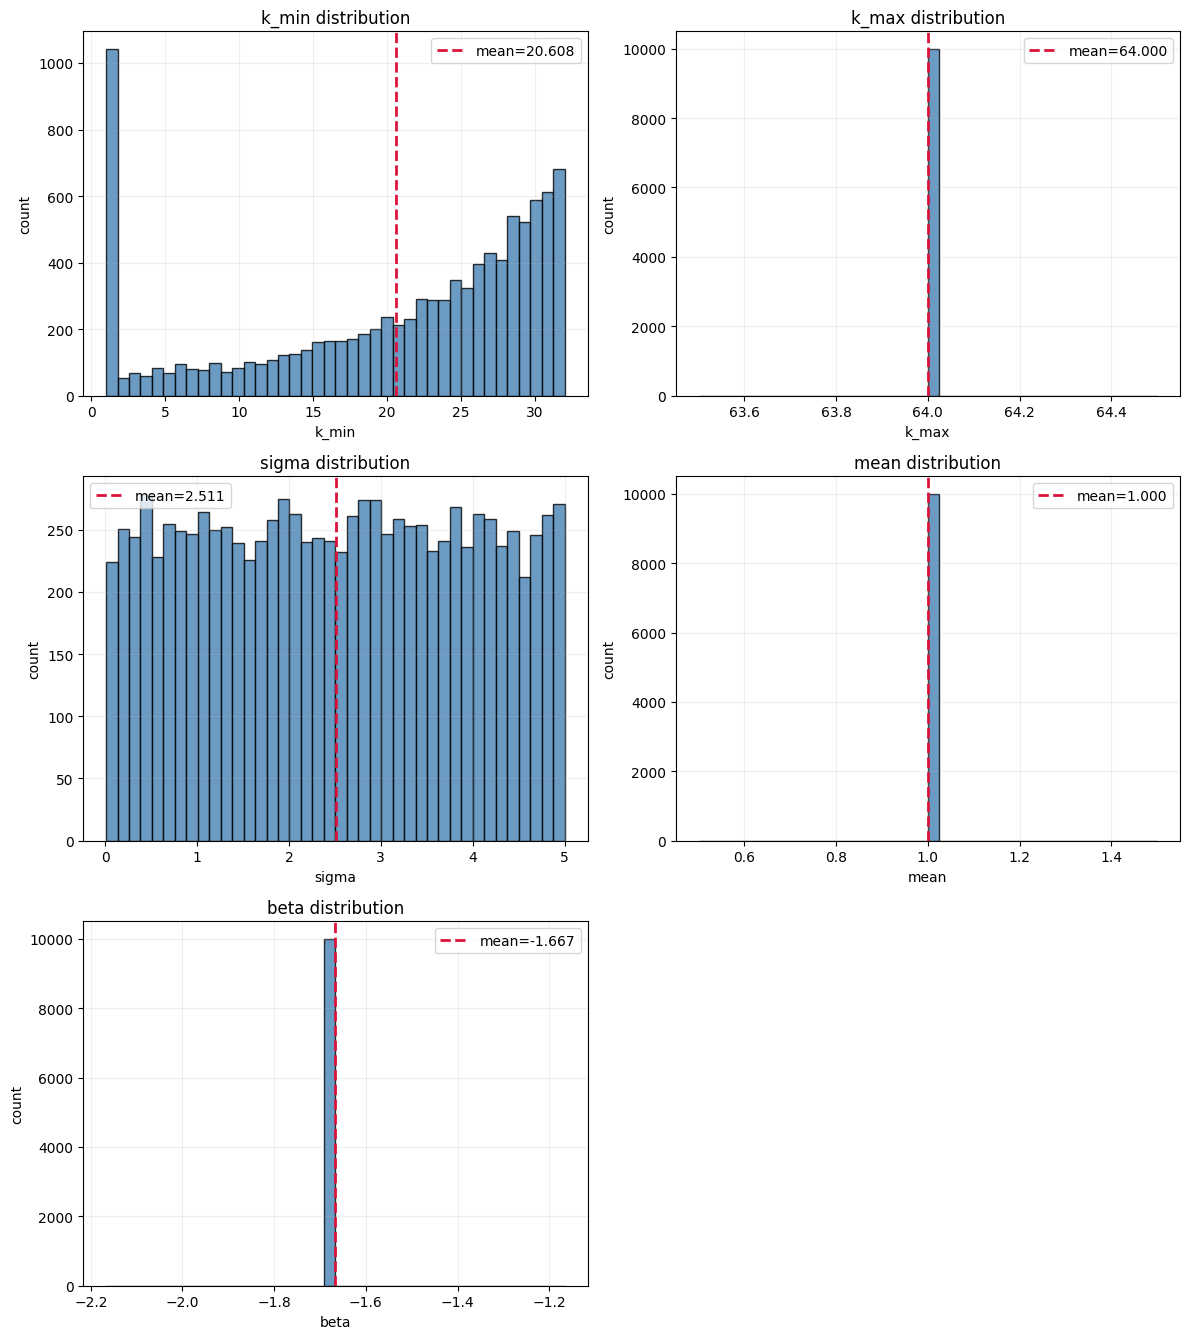

Verified distributions for flexible_20260419_132127_128x128_10000.h5
k_min | min=  1.000 max= 31.999 mean= 20.608 p05=  1.000 p50= 23.843 p95= 31.447
k_max | min= 64.000 max= 64.000 mean= 64.000 p05= 64.000 p50= 64.000 p95= 64.000
sigma | min=  0.011 max=  5.000 mean=  2.511 p05=  0.275 p50=  2.518 p95=  4.768
 mean | min=  1.000 max=  1.000 mean=  1.000 p05=  1.000 p50=  1.000 p95=  1.000
 beta | min= -1.667 max= -1.667 mean= -1.667 p05= -1.667 p50= -1.667 p95= -1.667


In [14]:
if 'latest_file' not in globals():
    raise RuntimeError("Run the previous cell first to define latest_file.")

with h5py.File(latest_file, 'r') as f:
    params = f['parameters']

    # Plot available parameter distributions.
    keys = [k for k in ['k_min', 'k_max', 'sigma', 'mean', 'beta'] if k in params]
    values = {k: params[k][:] for k in keys}

n_cols = 2
n_rows = int(np.ceil(len(values) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4.5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, key in zip(axes, values.keys()):
    arr = values[key]
    ax.hist(arr, bins=40, color='steelblue', alpha=0.8, edgecolor='black')
    ax.axvline(arr.mean(), color='crimson', linestyle='--', linewidth=2, label=f"mean={arr.mean():.3f}")
    ax.set_title(f"{key} distribution")
    ax.set_xlabel(key)
    ax.set_ylabel('count')
    ax.grid(alpha=0.2)
    ax.legend()

for ax in axes[len(values):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Verified distributions for {latest_file.name}")
for key, arr in values.items():
    q05, q50, q95 = np.percentile(arr, [5, 50, 95])
    print(f"{key:>5} | min={arr.min():7.3f} max={arr.max():7.3f} mean={arr.mean():7.3f} p05={q05:7.3f} p50={q50:7.3f} p95={q95:7.3f}")